In [4]:
import pandas as pd

df = pd.read_csv("reto.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])

x=9

Cargamos el dataset previamente limpiado para realizar el análisis exploratorio.

C:\Users\ludiw\AppData\Local\Temp\ipykernel_16628\2715920063.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')['total_interactions'].sum()


<Axes: title={'center': 'Evolución mensual de las interacciones'}, xlabel='timestamp'>

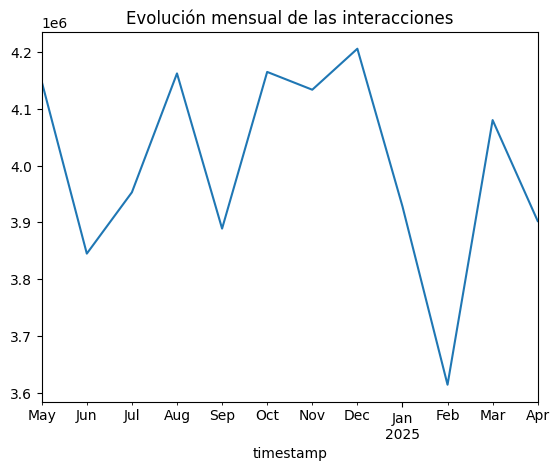

In [9]:
interacciones_mes = df.set_index('timestamp') \
                            .resample('M')['total_interactions'].sum()

interacciones_mes.plot(title='Evolución mensual de las interacciones')

Agrupamos las interacciones por mes y luego hacemos un grafico para ver se sea hecho bien

In [6]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['año'] = df['timestamp'].dt.year
df['mes'] = df['timestamp'].dt.month
df['día'] = df['timestamp'].dt.day
df['hora'] = df['timestamp'].dt.hour
df['nombre_mes'] = df['timestamp'].dt.strftime('%B')
df['día_semana'] = df['timestamp'].dt.day_name()
print(df[['timestamp', 'año', 'mes', 'día', 'hora', 'nombre_mes', 'día_semana']].head())

            timestamp   año  mes  día  hora nombre_mes día_semana
0 2024-12-09 11:26:15  2024   12    9    11   December     Monday
1 2024-07-28 19:59:26  2024    7   28    19       July     Sunday
2 2024-11-23 14:00:12  2024   11   23    14   November   Saturday
3 2024-09-16 04:35:25  2024    9   16     4  September     Monday
4 2024-09-05 21:03:01  2024    9    5    21  September   Thursday


Este bloque utilizamos para extraer información temporal detallada de la columna de fecha y hora. Permite analizar la actividad de los usuarios por año, mes, día, hora y día de la semana, facilitando la identificación de patrones temporales y tendencias en las interacciones y publicaciones.

In [8]:
df['total_interactions'] = df['likes_count'] + df['comments_count'] + df['shares_count']

Esta columna se crea para calcular el total de interacciones de cada publicación sumando “me gusta”, comentarios y compartidos. Permite analizar el engagement global de los usuarios y facilita la creación de métricas agregadas para comparar publicaciones, días, meses o categorías.

In [ ]:
df[['likes_count', 'comments_count', 'shares_count', 'total_interactions']].head()

,likes_count,comments_count,shares_count,total_interactions
0,1264,701,1704,3669
1,522,359,1803,2684
2,2689,643,705,4037
3,1827,743,262,2832
4,2005,703,1443,4151


Y aqui comprobamos si sean creado y que nos funciona correctamente

In [ ]:
top_posts = df.sort_values('total_interactions', ascending=False).head(10)
top_posts[['post_id', 'campaign_name', 'total_interactions']]

,post_id,campaign_name,total_interactions
459,7v5a8zyj4gw5,BlackFriday,7900
11947,ycjj5zzt7mvx,BackToSchool,7893
8925,3dh1ecglz4bd,CyberMonday,7817
3075,wo7py9aljg3t,NextGeneration,7793
1770,gmoeib832zbs,ValentinesDeals,7764
6899,5kvuyvf38nqx,ReferralBonus,7755
11154,pvfl3d8hj7jd,CyberMonday,7738
4093,tdgjjylpua20,SpringBlast2025,7723
3881,tne7s3o4l4wd,WinterWonders,7712
6398,kwt9yuwjsw74,InnovationX,7685


Este bloque selecciona los 10 posts con mayor número de interacciones, permitiendo identificar las publicaciones más exitosas y las campañas que generan mayor engagement. Esta información es útil para evaluar estrategias de contenido y comprender los factores que impulsan la participación de los usuarios.

In [ ]:
df.groupby('campaign_name')['total_interactions'].mean().sort_values(ascending=False)

campaign_name
SummerDreams             4136.590998
CustomerFirst            4071.549213
ValentinesDeals          4060.584615
EarthDay                 4058.362035
NextGeneration           4057.109312
LoyaltyRewards           4049.941392
DigitalTransformation    4034.231405
LocalTouchpoints         4033.465608
BackToSchool             4021.702555
WinterWonders            4020.102804
FallCollection           4003.380000
HolidaySpecial           4003.027027
CyberMonday              3998.987784
LaunchWave               3982.366300
InnovationX              3980.807143
SpringBlast2025          3980.747059
NewYearNewYou            3971.151093
BlackFriday              3959.373253
PowerRelease             3954.469667
SustainableFuture        3942.430862
ReferralBonus            3920.027344
SummerSale               3915.281664
GlobalCampaign           3894.536965
Name: total_interactions, dtype: float64

Este bloque calculamos la interacción promedio por campaña, permitiendo identificar cuáles generan mayor participación de los usuarios. Esto facilita la comparación de campañas y proporciona información valiosa para evaluar la efectividad de la estrategia de contenido en la red social.

In [ ]:
df['weekday'] = df['timestamp'].dt.day_name()

print(df[['timestamp', 'weekday']].head())

            timestamp   weekday
0 2024-12-09 11:26:15    Monday
1 2024-07-28 19:59:26    Sunday
2 2024-11-23 14:00:12  Saturday
3 2024-09-16 04:35:25    Monday
4 2024-09-05 21:03:01  Thursday


Esta columna se crea para identificar el día de la semana de cada publicación, lo que permite analizar la distribución de la actividad de los usuarios a lo largo de la semana y detectar patrones semanales de comportamiento o interacción.

In [ ]:
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
posts_por_dia = df['weekday'].value_counts().reindex(days_order, fill_value=0)

print(posts_por_dia)

weekday
Monday       1720
Tuesday      1677
Wednesday    1771
Thursday     1718
Friday       1723
Saturday     1675
Sunday       1716
Name: count, dtype: int64


Este bloque calculamos la cantidad de publicaciones por día de la semana, permitiendo analizar los patrones semanales de actividad de los usuarios y detectar los días con mayor o menor participación en la red social.

In [ ]:
df.groupby('platform')['engagement_rate'].mean().sort_values(ascending=False)

platform
Instagram    0.287131
Facebook     0.286412
YouTube      0.279185
Reddit       0.278727
Twitter      0.259331
Name: engagement_rate, dtype: float64

Este bloque calculamos la tasa promedio de engagement por plataforma, permitiendo identificar cuáles generan mayor participación de los usuarios. Esta información es útil para evaluar el desempeño de cada red social y orientar decisiones estratégicas sobre la distribución de contenido.

In [ ]:
df.groupby('sentiment_score')['total_interactions'].mean()

sentiment_score
-0.9998    1891.0
-0.9997    4197.5
-0.9996    4219.0
-0.9995    5614.5
-0.9993    3011.0
            ...  
 0.9990    2821.0
 0.9996    2951.5
 0.9997    4163.0
 0.9998    2550.0
 0.9999    3490.0
Name: total_interactions, Length: 9038, dtype: float64

Este bloque calculamos la interacción promedio de las publicaciones según su puntaje de sentimiento, permitiendo identificar si los posts con cierto tono emocional generan más engagement. Esta información ayuda a comprender la relación entre el sentimiento del contenido y la participación de los usuarios.

In [ ]:
df.groupby('user_id')['total_interactions'].sum() \
  .sort_values(ascending=False).head(10)

user_id
user_qbclaspk    7900
user_3w27ggio    7893
user_np966onv    7817
user_50qjuqdj    7793
user_kk1decwg    7764
user_n6p8x5xw    7755
user_jwq9kwt4    7738
user_j2o4po42    7723
user_ix1d6h8j    7712
user_oa2wz7nx    7685
Name: total_interactions, dtype: int64

Este bloque calculamos el total de interacciones por usuario y selecciona los 10 con mayor actividad. Permite identificar los usuarios más influyentes en la red social y entender cómo se distribuye la participación entre los miembros de la comunidad.

In [ ]:
df.head()

,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,hashtags,mentions,...,comments_count,impressions,engagement_rate,brand_name,product_name,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
0,kcqbs6hxybia,2024-12-09 11:26:15,Monday,Instagram,user_52nwb0a6,"Melbourne, Australia",pt,Just tried the Chromebook from Google. Best pu...,#Food,NaN,...,701,18991,0.19319,Google,Chromebook,BlackFriday,Launch,0.0953,-0.3672,19.1
1,vkmervg4ioos,2024-07-28 19:59:26,Sunday,Twitter,user_ucryct98,"Tokyo, Japan",ru,Just saw an ad for Microsoft Surface Laptop du...,"#MustHave, #Food","@CustomerService, @BrandCEO",...,359,52764,0.05086,Microsoft,Surface Laptop,PowerRelease,Post-Launch,0.1369,-0.4510,-42.6
2,memhx4o1x6yu,2024-11-23 14:00:12,Saturday,Reddit,user_7rrev126,"Beijing, China",ru,What's your opinion about Nike's Epic React? ...,"#Promo, #Food, #Trending",NaN,...,643,8887,0.45425,Nike,Epic React,BlackFriday,Post-Launch,0.2855,-0.4112,17.4
3,bhyo6piijqt9,2024-09-16 04:35:25,Monday,YouTube,user_4mxuq0ax,"Lagos, Nigeria",en,Bummed out with my new Diet Pepsi from Pepsi! ...,"#Reviews, #Sustainable","@StyleGuide, @BrandSupport",...,743,6696,0.42293,Pepsi,Diet Pepsi,LaunchWave,Launch,-0.2094,-0.0167,-5.5
4,c9dkiomowakt,2024-09-05 21:03:01,Thursday,Twitter,user_l1vpox2k,"Berlin, Germany",hi,Just tried the Corolla from Toyota. Absolutely...,"#Health, #Travel","@BrandSupport, @InfluencerName",...,703,47315,0.08773,Toyota,Corolla,LocalTouchpoints,Launch,0.6867,0.0807,38.8


In [ ]:
df.groupby('campaign_name').size().sum()

np.int64(12000)

Este bloque calculamos el total de publicaciones agrupadas por campaña, sumando todas las publicaciones. Permite comprobar la consistencia de los datos y sirve como referencia para calcular la participación relativa de cada campaña en la red social.

In [ ]:
df.groupby('campaign_name').size().max()

np.int64(573)

Este bloque calculamos el número máximo de publicaciones realizadas en una campaña, permitiendo identificar cuál fue la más activa. Esta información ayuda a comprender la distribución del contenido y a detectar campañas que concentran la mayor parte de las publicaciones en la red social

In [ ]:
df.groupby('campaign_name', ).size()

campaign_name
BackToSchool             548
BlackFriday              501
CustomerFirst            508
CyberMonday              573
DigitalTransformation    484
EarthDay                 511
FallCollection           500
GlobalCampaign           514
HolidaySpecial           518
InnovationX              560
LaunchWave               546
LocalTouchpoints         567
LoyaltyRewards           546
NewYearNewYou            503
NextGeneration           494
PowerRelease             511
ReferralBonus            512
SpringBlast2025          510
SummerDreams             511
SummerSale               529
SustainableFuture        499
ValentinesDeals          520
WinterWonders            535
dtype: int64

Este bloque calculamos el número de publicaciones por campaña, permitiendo analizar la distribución del contenido entre las distintas campañas de la red social y detectar aquellas que concentran mayor o menor cantidad de publicaciones.